In [11]:
# Cell 1 — setup
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config.settings import BRONZE_DIR, SILVER_DIR
from data.timetable import (
    add_segment_type,
    add_dynamics,
    add_period,
    add_time_in_seconds,
    add_train_type,
)

DISTRIBUTIONS_DIR = Path.cwd().parent / 'data' / 'distributions'
DISTRIBUTIONS_DIR.mkdir(parents=True, exist_ok=True)

# Grens disturbance vs disruption (seconden)
# Rijtijden buiten [PLANNED * MIN_FACTOR, PLANNED * MAX_FACTOR] worden als disruption beschouwd
MIN_FACTOR = 0.3   # rijtijd minder dan 30% van gepland → disruption
MAX_FACTOR = 3.0   # rijtijd meer dan 300% van gepland → disruption

In [12]:
# Cell 2 — laad brons
bronze_files = sorted(BRONZE_DIR.glob('*.parquet'))
df = pd.concat([pd.read_parquet(f) for f in bronze_files], ignore_index=True)
print(f"{df['DATDEP'].nunique()} dagen, {df['TRAIN_NO'].nunique()} treinen, {len(df)} rijen")
print(f"Datumrange: {df['DATDEP'].min()} → {df['DATDEP'].max()}")

260 dagen, 1367 treinen, 2847682 rijen
Datumrange: 2025-03-03 00:00:00 → 2026-02-27 00:00:00


In [13]:
# Cell 3 — verrijking (geen aggregatie, alle dagen behouden)
# assign_platforms wordt NIET toegepast: platformtoewijzing is een eigenschap
# van de geplande timetable, niet van individuele observaties.
# SECTION blijft zonder platform suffix — rijtijden worden gemeten per fysieke sectie.
df['LINE_NO_DEP'] = df['LINE_NO_DEP'].str.replace('/', '-')
dwell_mask = df['SOURCE'] == df['TARGET']
df['SECTION'] = np.where(
    dwell_mask,
    df['SOURCE'].astype(str),
    df['LINE_NO_DEP'].astype(str) + ':' + df['SOURCE'].astype(str) + '-' + df['TARGET'].astype(str)
)

df = add_segment_type(df)    # vereist PLANNED_DEPARTURE/ARRIVAL als datetime, vóór add_time_in_seconds
df = add_dynamics(df)        # vereist TYPE
df = add_period(df)          # vereist PLANNED_ARRIVAL als datetime, vóór add_time_in_seconds
df = add_time_in_seconds(df) # converteert PLANNED_DEPARTURE/ARRIVAL naar ENTRY/EXIT_SECONDS
df = add_train_type(df)      # vereist RELATION_DIRECTION

df = df[df['TYPE'] != 'WITHIN-STATION-PASSING']

print(f"{df['SECTION'].nunique()} unieke secties, {len(df)} observaties")
print(f"Dynamics:   {df['DYNAMICS'].value_counts().to_dict()}")
print(f"Periodes:   {df['PERIOD'].value_counts().to_dict()}")
print(f"Traintypes: {df['TRAIN_TYPE'].value_counts().to_dict()}")



104 unieke secties, 2186669 observaties
Dynamics:   {'0-0': 917786, 'ACC-0': 527185, '0-BR': 525354, 'ACC-BR': 216344}
Periodes:   {'DAYTIME': 880673, 'EVENING': 482645, 'EVENING PEAK': 381933, 'MORNING PEAK': 362167, 'NIGHT': 79251}
Traintypes: {'IC': 1299148, 'L': 598767, 'S': 170863, 'EURST': 57342, 'INT': 37866, 'ICE': 22669, 'TGV': 14}


In [14]:
# Cell 4 — bereken rijtijden in seconden
# ENTRY_SECONDS en EXIT_SECONDS zijn al correct geswapt door add_time_in_seconds
df['RUNNING_TIME_PLANNED'] = df['EXIT_SECONDS'] - df['ENTRY_SECONDS']

# Werkelijke rijtijd: zelfde swap-logica toepassen op real tijden
df['REAL_DEPARTURE'] = pd.to_datetime(df['REAL_DEPARTURE'])
df['REAL_ARRIVAL']   = pd.to_datetime(df['REAL_ARRIVAL'])

dwell_mask = df['SOURCE'] == df['TARGET']
needs_swap = dwell_mask & (df['REAL_DEPARTURE'] > df['REAL_ARRIVAL'])

df['REAL_ENTRY'] = df['REAL_DEPARTURE']
df['REAL_EXIT']  = df['REAL_ARRIVAL']
df.loc[needs_swap, 'REAL_ENTRY'] = df.loc[needs_swap, 'REAL_ARRIVAL']
df.loc[needs_swap, 'REAL_EXIT']  = df.loc[needs_swap, 'REAL_DEPARTURE']

df['RUNNING_TIME_REAL'] = (df['REAL_EXIT'] - df['REAL_ENTRY']).dt.total_seconds()

n_before = len(df)
df = df.dropna(subset=['RUNNING_TIME_REAL', 'RUNNING_TIME_PLANNED'])
df = df[df['RUNNING_TIME_REAL']    > 0]
df = df[df['RUNNING_TIME_PLANNED'] > 0]
print(f"{n_before - len(df)} rijen verwijderd")
print(f"{len(df)} observaties beschikbaar")

2328 rijen verwijderd
2184341 observaties beschikbaar


=== Rijtijdstatistieken ===
       RUNNING_TIME_REAL  RUNNING_TIME_PLANNED
count          2184341.0             2184341.0
mean               147.6                 142.8
std                108.2                 109.2
min                  1.0                   5.0
25%                 91.0                 120.0
50%                125.0                 120.0
75%                173.0                 180.0
max              20171.0               86650.0

Ratio werkelijk/gepland:
count    2184341.000
mean           1.121
std            0.747
min            0.003
25%            0.808
50%            1.017
75%            1.233
max          336.183
Name: RT_RATIO, dtype: float64

Ratio < 0.3 (te snel): 1643
Ratio > 3.0 (te traag): 26192


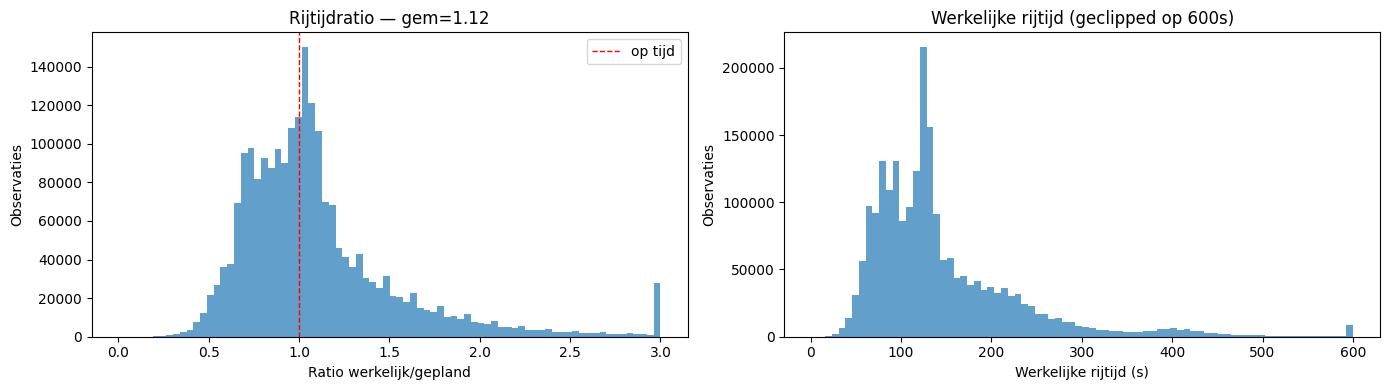

In [15]:
# Cell 5 — validatie rijtijden
print("=== Rijtijdstatistieken ===")
print(df[['RUNNING_TIME_REAL', 'RUNNING_TIME_PLANNED']].describe().round(1))

# Ratio werkelijk/gepland — geeft inzicht in typische vertraging
df['RT_RATIO'] = df['RUNNING_TIME_REAL'] / df['RUNNING_TIME_PLANNED']
print(f"\nRatio werkelijk/gepland:")
print(df['RT_RATIO'].describe().round(3))
print(f"\nRatio < {MIN_FACTOR} (te snel): {(df['RT_RATIO'] < MIN_FACTOR).sum()}")
print(f"Ratio > {MAX_FACTOR} (te traag): {(df['RT_RATIO'] > MAX_FACTOR).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['RT_RATIO'].clip(0, 3), bins=80, edgecolor='none', alpha=0.7)
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=1, label='op tijd')
axes[0].set_xlabel('Ratio werkelijk/gepland')
axes[0].set_ylabel('Observaties')
axes[0].set_title(f'Rijtijdratio — gem={df["RT_RATIO"].mean():.2f}')
axes[0].legend()

axes[1].hist(df['RUNNING_TIME_REAL'].clip(0, 600), bins=80, edgecolor='none', alpha=0.7)
axes[1].set_xlabel('Werkelijke rijtijd (s)')
axes[1].set_ylabel('Observaties')
axes[1].set_title('Werkelijke rijtijd (geclipped op 600s)')
plt.tight_layout()
plt.show()

In [16]:
# Cell 6 — filter disruptions
# Behoud enkel disturbances: rijtijden binnen [MIN_FACTOR, MAX_FACTOR] × gepland
n_before = len(df)
df_dist = df[
    (df['RT_RATIO'] >= MIN_FACTOR) &
    (df['RT_RATIO'] <= MAX_FACTOR)
].copy()
print(f"{n_before - len(df_dist)} observaties verwijderd als disruption")
print(f"{len(df_dist)} observaties behouden ({100*len(df_dist)/n_before:.1f}% van totaal)")

27835 observaties verwijderd als disruption
2156506 observaties behouden (98.7% van totaal)


In [17]:
# Distributies opbouwen
# Empirisch: werkelijke rijtijden per cel opgeslagen als gesorteerde lijst
# Sampling in simulatie via np.random.choice(values)
# Structuur: distributions[section][train_type][dynamics][period]
#   → { 'real': [float, ...], 'planned': float, 'n': int }
# 'planned' is de mediane geplande rijtijd voor die cel (referentie)
distributions = {}
n_cells = 0

for (section, train_type, dynamics, period), group in df_dist.groupby(
    ['SECTION', 'TRAIN_TYPE', 'DYNAMICS', 'PERIOD']
):
    real_values = group['RUNNING_TIME_REAL'].dropna().round(1).sort_values().tolist()

    if not real_values:
        continue

    distributions \
        .setdefault(section, {}) \
        .setdefault(train_type, {}) \
        .setdefault(dynamics, {})[period] = {
            'real':    real_values,
            'n':       len(real_values),
        }
    n_cells += 1

print(f"Cellen opgeslagen: {n_cells}")
print(f"Unieke secties:    {len(distributions)}")

Cellen opgeslagen: 2746
Unieke secties:    103


In [18]:
# Cell 9 — opslaan
output_path = DISTRIBUTIONS_DIR / 'running_distributions.json'
with open(output_path, 'w') as f:
    json.dump(distributions, f)
size_mb = output_path.stat().st_size / (1024 * 1024)
print(f"Opgeslagen: {output_path} ({size_mb:.2f} MB)")

Opgeslagen: /Users/ddw/Desktop/Rescheduling/data/distributions/running_distributions.json (13.85 MB)


Voorbeeldcel: 0-1:BRUSSEL-CENTRAAL-BRUSSEL-CONGRES | EURST | 0-0 | DAYTIME
  n=2513
  real (eerste 10): [63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0, 63.0]


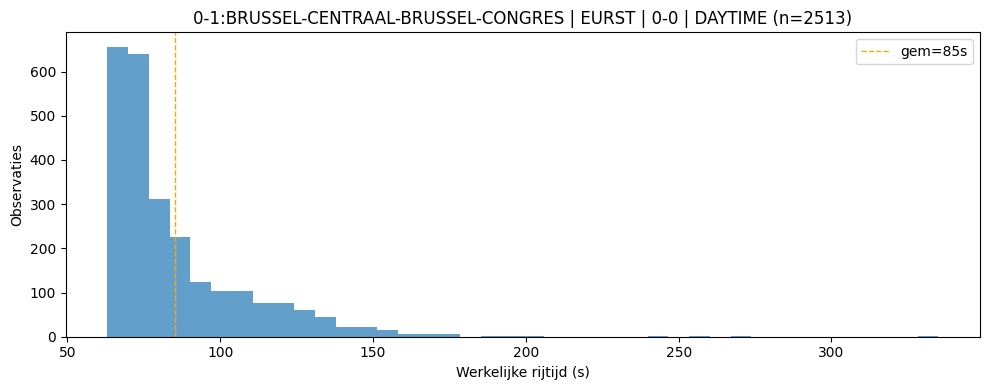

In [19]:
# Cell 10 — validatie output
with open(DISTRIBUTIONS_DIR / 'running_distributions.json') as f:
    loaded = json.load(f)

example_section    = next(iter(loaded))
example_train_type = next(iter(loaded[example_section]))
example_dynamics   = next(iter(loaded[example_section][example_train_type]))
example_period     = next(iter(loaded[example_section][example_train_type][example_dynamics]))
example_cell       = loaded[example_section][example_train_type][example_dynamics][example_period]

print(f"Voorbeeldcel: {example_section} | {example_train_type} | {example_dynamics} | {example_period}")
print(f"  n={example_cell['n']}")
print(f"  real (eerste 10): {example_cell['real'][:10]}")

real_vals = np.array(example_cell['real'])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(real_vals, bins=40, edgecolor='none', alpha=0.7)
ax.axvline(float(np.mean(real_vals)), color='orange', linestyle='--', linewidth=1,
           label=f'gem={np.mean(real_vals):.0f}s')
ax.set_xlabel('Werkelijke rijtijd (s)')
ax.set_ylabel('Observaties')
ax.set_title(
    f'{example_section} | {example_train_type} | {example_dynamics} | {example_period} (n={len(real_vals)})'
)
ax.legend()
plt.tight_layout()
plt.show()